# Marginal Emission Factors

This notebook documents the code used for methodology relating the the exploration and estimation of marginal emission factors (MEFs).

## Importing the Data and Dependencies

Importing required packages:

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib as mpl
from scipy.stats import linregress

Mounting to Google Drive:

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


Import historic data on fuel-specific electricity generation from Elexon, available at: https://bmrs.elexon.co.uk/generation-by-fuel-type. The data includes observations between 1 August 2022 - 31 July 2025.

In [3]:
generation = pd.read_csv('/content/drive/MyDrive/ERP/Raw_Data/generation_by_fuel_type.csv')
generation.head(10)

,Dataset,PublishTime,StartTime,SettlementDate,SettlementPeriod,FuelType,Generation
0,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,BIOMASS,1346
1,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,CCGT,7815
2,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,COAL,0
3,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,INTELEC,0
4,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,INTEW,8
5,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,INTFR,-146
6,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,INTIFA2,-236
7,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,INTIRL,8
8,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,INTNED,100
9,FUELHH,2022-08-06T23:30:00Z,2022-08-06T23:00:00Z,2022-08-07,1,INTNEM,88


## Pre-processing

Pivoting to create rows of observations:

In [4]:
gen = (
    generation.loc[:, ['StartTime', 'FuelType', 'Generation']]
      .assign(
          PublishTime=pd.to_datetime(generation['StartTime'], errors='coerce', utc=True),
          Generation=pd.to_numeric(generation['Generation'], errors='coerce')
      )
      .pivot_table(index='StartTime', columns='FuelType', values='Generation', aggfunc='sum')
      .sort_index()
      .reset_index()
      .rename(columns={'StartTime': 'date_time'})
)

Removing observations outside of the desired timeframe

In [5]:
gen["date_time"] = pd.to_datetime(gen["date_time"], errors="coerce").dt.tz_localize(None)
gen = gen[(gen["date_time"] >= pd.Timestamp("2022-08-01")) & (gen["date_time"] <= pd.Timestamp("2025-07-31"))].reset_index(drop=True)
len(gen['date_time'])

52557

Renaming columns and attributing interconnectors to importing countries:

In [6]:
gen = gen.rename(columns={'CCGT': 'gas',
                        'INTIRL': 'northern_ireland',
                        'INTNED': 'netherlands',
                        'INTNEM': 'belgium',
                        'INTNSL': 'norway',
                        'NPSHYD': 'hydro',
                        'OCGT': 'gas (open_cycle)',
                        'PS': 'pumped_storage',
                        'INTVKL': 'denmark'})

gen['france'] = gen['INTFR'] + gen['INTIFA2'] + gen['INTELEC']
gen['ireland'] = gen['INTEW'] + gen['INTGRNL']
gen.drop(columns=['INTFR', 'INTIFA2', 'INTELEC', 'INTEW', 'INTGRNL'], inplace=True)

gen.columns = [col.lower() for col in gen.columns]

Inspecting for missing data, negative values, and duplicate rows:

In [7]:
print("Number of missing values:\n",gen.isna().sum())
print("\nNumber of negative values:\n",(gen.select_dtypes(include=np.number) < 0).sum())
print("\nNumber of duplicate observations:\n",gen.duplicated().sum().sum())

Number of missing values:
 date_time               0
biomass                 0
gas                     0
coal                    0
northern_ireland        0
netherlands             0
belgium                 0
norway                  0
denmark             22954
hydro                   0
nuclear                 0
gas (open_cycle)        0
oil                     0
other                   0
pumped_storage          0
wind                    0
france                  0
ireland             35327
dtype: int64

Number of negative values:
 biomass                 0
gas                     0
coal                    0
northern_ireland    39561
netherlands         17059
belgium             15633
norway               6365
denmark              7584
hydro                   0
nuclear                 0
gas (open_cycle)        0
oil                     0
other                   0
pumped_storage      28465
wind                    0
france              11970
ireland             14234
dtype: int64

Number 

Negative values from importing countries relate to net exports from the UK. This is equivalent to no imports so values are capped to a minimum of zero. NaN values, which predate recordings from Irish and Danish imports, are also converted to 0.

In [8]:
all_fuels = [c for c in gen.columns if c not in ['date_time']]
gen[all_fuels] = gen[all_fuels].clip(lower=0)
gen = gen.fillna(0)

Converting measurements from MW to kW:

In [9]:
gen[all_fuels] = gen[all_fuels] * 1000

Creating a varibale for cumulative generation from all sources:

In [10]:
gen['generation'] = gen[all_fuels].sum(axis=1)

Creating variables for months, times and days:

In [11]:
gen["date_time"] = pd.to_datetime(gen["date_time"], errors="coerce")

# extracting the time of day
gen["time"] = gen["date_time"].dt.time

# extracting the hour of day
gen["hour"] = gen["date_time"].dt.hour

# extracting the month of the year
gen["month"] = gen["date_time"].dt.month

# extracting the day of the week
gen["weekday"] = gen["date_time"].dt.weekday

# reordering columns
gen = gen.loc[:, ["date_time","time", "hour", "month", "weekday"] +
                             [c for c in gen.columns if c not in ["date_time", "time", "hour", "month", "weekday"]]]

## Exploratory Analysis

Plotting the average contribution of each fuel type to total generation over a 24-hour period. For the clarity of the image, small contributing sources are merged into one observations.

/tmp/ipython-input-1637769027.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  idx_parsed = pd.to_datetime(idx.astype(str), errors="coerce")


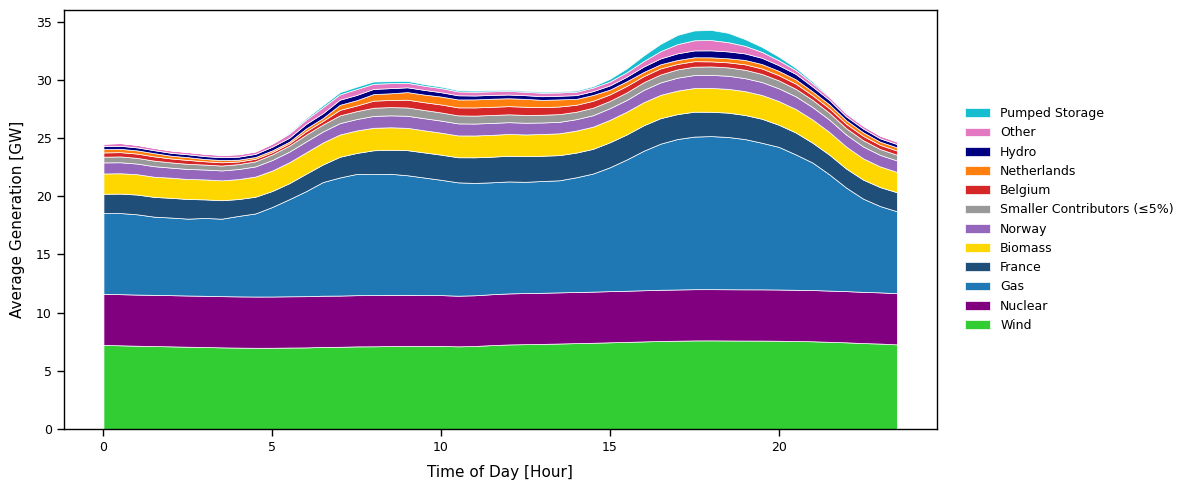

In [12]:
small_contributors = [
    "coal", "northern_ireland", "denmark",
    "gas (open_cycle)", "oil", "ireland"
]

small_cols = [f for f in small_contributors if f in all_fuels]
major_cols = [f for f in all_fuels if f not in small_cols]
fuel_means = gen.groupby("time")[major_cols + small_cols].mean(numeric_only=True)

if small_cols:
    fuel_means["Smaller Contributors (≤5%)"] = fuel_means[small_cols].sum(axis=1)
    plot_cols = major_cols + ["Smaller Contributors (≤5%)"]
else:
    plot_cols = major_cols[:]

idx = fuel_means.index
use_time_formatter = False
try:
    idx_parsed = pd.to_datetime(idx.astype(str), errors="coerce")
    if idx_parsed.notna().all():
        x = idx_parsed.to_numpy()
        use_time_formatter = True
    else:
        x = idx.to_numpy()
except Exception:
    x = idx.to_numpy()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates

order_by_mean = fuel_means[plot_cols].mean().sort_values(ascending=False).index.tolist()

if 'gas' in order_by_mean:
    base = [f for f in order_by_mean if f != 'gas']
    if 'france' in base:
        i = base.index('france')
        ordered_for_plot = base[:i] + ['gas', 'france'] + base[i+1:]
    else:
        ordered_for_plot = ['gas'] + base
else:
    ordered_for_plot = order_by_mean

Y = np.vstack([fuel_means[c].to_numpy() for c in ordered_for_plot]) / 1_000_000

fig, ax = plt.subplots(figsize=(12, 5))

palette = {
    'france': '#1f4e79',
    'small_contributors': '#8B4513',
    'wind': 'limegreen',
    'gas': 'tab:blue',
    'pumped_storage': 'tab:cyan',
    'norway': 'tab:purple',
    'biomass': '#FFD700',
    'hydro': '#000080',
    'other': 'tab:pink',
    'netherlands': 'tab:orange',
    'belgium': 'tab:red',
    'nuclear': 'purple'
}

colors = [palette.get(f, '#999999') for f in ordered_for_plot]

layers = ax.stackplot(
    x, Y, labels=ordered_for_plot,
    colors=colors, edgecolor="white", linewidth=0.5
)

ax.set_ylabel("Average Generation [GW]", fontsize=11, labelpad=8)

if use_time_formatter:
    ax.set_xlabel("Time of Day [Hour]", fontsize=11, labelpad=8)
    ticks_hours = [0, 5, 10, 15, 20]
    base_date = pd.to_datetime(idx_parsed[0]).normalize()
    tick_positions = [base_date + pd.Timedelta(hours=h) for h in ticks_hours]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([str(h) for h in ticks_hours])
else:
    ax.set_xlabel("Hour of Day", fontsize=11, labelpad=8)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_xticklabels(["0", "4", "8", "12", "16", "20"])

ax.tick_params(axis="both", length=5, width=1, labelsize=9)

handles, labels = ax.get_legend_handles_labels()
labels_pretty = [lbl.replace('_', ' ').title() for lbl in labels[::-1]]
ax.legend(handles[::-1], labels_pretty, loc="center left",
          bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)

for s in ax.spines.values():
    s.set_visible(True)
    s.set_linewidth(1)

plt.tight_layout()
plt.show()


Assessing which fuel type has the greatest proportional variance:

In [13]:
cols_for_stats = plot_cols
df = fuel_means[cols_for_stats]

means = df.mean()
vars_ = df.var(ddof=0)

prop_var = (vars_ / means).replace([np.inf, -np.inf], np.nan).sort_values(ascending=False)

print("\nFuel types ordered by proportional variance:\n")
for fuel, val in prop_var.items():
    pretty = fuel.replace('_', ' ').title()
    val_str = "NaN" if pd.isna(val) else f"{val:.3f}"
    print(f"{pretty:30s} {val_str}")


Fuel types ordered by proportional variance:

Gas                            433537.989
Pumped Storage                 290836.595
Other                          86137.407
Netherlands                    70997.145
Belgium                        48442.108
France                         39669.818
Hydro                          28024.093
Smaller Contributors (≤5%)     16502.797
Wind                           6164.768
Biomass                        6038.734
Norway                         6017.193
Nuclear                        32.556


Looking at temporal trends:

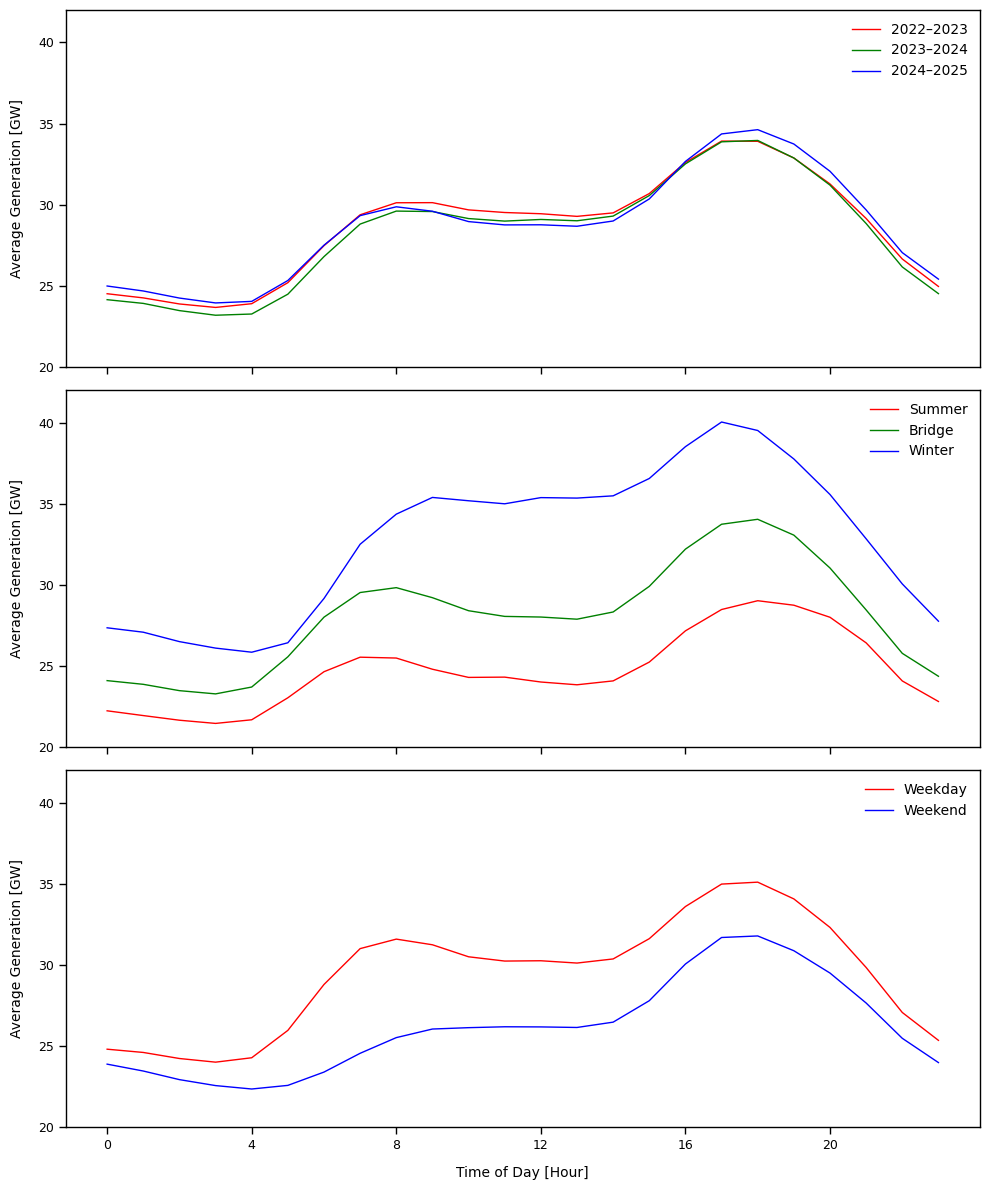

In [14]:
annual_periods = [
    ("2022–2023", pd.Timestamp("2022-08-01"), pd.Timestamp("2023-07-31")),
    ("2023–2024", pd.Timestamp("2023-08-01"), pd.Timestamp("2024-07-31")),
    ("2024–2025", pd.Timestamp("2024-08-01"), pd.Timestamp("2025-07-31")),
]

seasons = [
    ("Summer", [5, 6, 7, 8], "r"),
    ("Bridge", [3, 4, 9, 10], "g"),
    ("Winter", [11, 12, 1, 2], "b"),
]

day_groups = [
    ("Weekday", [0, 1, 2, 3, 4], "r"),
    ("Weekend", [5, 6], "b"),
]

import matplotlib.pyplot as plt
from matplotlib import ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

colours = ["r", "g", "b"]
ax = axes[0]
for (label, start, end), colour in zip(annual_periods, colours):
    sub = gen[(gen["date_time"] >= start) & (gen["date_time"] < end)]
    avg = sub.groupby("hour")["generation"].mean().reset_index()
    ax.plot(avg["hour"], avg["generation"] / 1_000_000, color=colour, linewidth=1, label=label)
ax.set_ylabel("Average Generation [GW]", fontsize=10, labelpad=10)
ax.set_xticks(range(0, 24, 4))
ax.set_xticklabels([])
ax.set_ylim(20, 42)
ax.set_yticks(range(20, 45, 5))
ax.tick_params(axis='both', length=5, width=1, labelsize=9)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

ax = axes[1]
for label, months, colour in seasons:
    sub = gen[gen["month"].isin(months)]
    avg = sub.groupby("hour")["generation"].mean().reset_index()
    ax.plot(avg["hour"], avg["generation"] / 1_000_000, color=colour, linewidth=1, label=label)
ax.set_ylabel("Average Generation [GW]", fontsize=10, labelpad=10)
ax.set_xticks(range(0, 24, 4))
ax.set_xticklabels([])
ax.set_ylim(20, 42)
ax.set_yticks(range(20, 45, 5))
ax.tick_params(axis='both', length=5, width=1, labelsize=9)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

ax = axes[2]
for label, days, colour in day_groups:
    sub = gen[gen["weekday"].isin(days)]
    avg = sub.groupby("hour")["generation"].mean().reset_index()
    ax.plot(avg["hour"], avg["generation"] / 1_000_000, color=colour, linewidth=1, label=label)
ax.set_xticks(range(0, 24, 4))
ax.set_xticklabels([str(h) for h in range(0, 24, 4)], fontsize=10)
ax.set_xlabel("Time of Day [Hour]", fontsize=10, labelpad=10)
ax.set_ylabel("Average Generation [GW]", fontsize=10, labelpad=10)
ax.set_ylim(20, 42)
ax.set_yticks(range(20, 45, 5))
ax.tick_params(axis='both', length=5, width=1, labelsize=9)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()


## Fuel-specific Emission Factors

Emission factors [gCO2/kWh] are combined with generation data to prodcue estimates of total carbon emissions [g] and average carbon intnesity [gCO2/kWh] per observation:

In [15]:
emission_factors = {

    'coal': 937,
    'oil': 935,
    'gas (open_cycle)': 651,
    'gas': 394,
    'other': 300,
    'biomass': 120,
    'hydro': 0,
    'nuclear': 0,
    'pumped_storage': 0,
    'wind': 0,

    'netherlands': 354,
    'ireland': 346,
    'northern_ireland': 346,
    'denmark': 180,
    'belgium': 167,
    'france': 85,
    'norway': 29
}

gen['carbon_emissions'] = (gen[all_fuels] * pd.Series(emission_factors)).sum(axis=1) * 0.5
gen['carbon_intensity'] = gen['carbon_emissions'] / (gen['generation'] * 0.5)


Creating an array of values for the average carbon intensity at each time interval:

In [16]:
carbon_intensity = gen['carbon_intensity'].groupby(gen['hour']).mean()

## Linear Regression

Creating the variable 'marginal generation' without wind and nuclear energy because they do not feature in the marginal mix

In [17]:
marginal_fuels = [f for f in all_fuels if f not in ['wind', 'nuclear']]
gen['marginal_generation'] = gen[marginal_fuels].sum(axis=1)

Creating a dataframe of first-differenced variables to explore changes between intervals:

In [18]:
gen_diff = gen.copy()
gen_diff.iloc[:, 5:] = gen_diff.iloc[:, 5:].astype(float).diff()
gen_diff = gen_diff.dropna()
gen_diff.head()

,date_time,time,hour,month,weekday,biomass,gas,coal,northern_ireland,netherlands,...,oil,other,pumped_storage,wind,france,ireland,generation,carbon_emissions,carbon_intensity,marginal_generation
1,2022-08-01 00:30:00,00:30:00,0,8,0,33000.0,-12000.0,1000.0,52000.0,0.0,...,0.0,3000.0,0.0,-89000.0,0.0,0.0,-15000.0,9856000.0,0.993135,78000.0
2,2022-08-01 01:00:00,01:00:00,1,8,0,15000.0,-104000.0,-1000.0,-32000.0,0.0,...,0.0,-41000.0,0.0,-186000.0,0.0,0.0,-345000.0,-31742500.0,1.928584,-163000.0
3,2022-08-01 01:30:00,01:30:00,1,8,0,-22000.0,-16000.0,-2000.0,10000.0,0.0,...,0.0,-19000.0,0.0,-159000.0,0.0,0.0,-225000.0,-6529000.0,2.463873,-68000.0
4,2022-08-01 02:00:00,02:00:00,2,8,0,-46000.0,-9000.0,4000.0,-10000.0,0.0,...,0.0,-3000.0,0.0,-97000.0,0.0,0.0,-164000.0,-4839000.0,1.818388,-67000.0
5,2022-08-01 02:30:00,02:30:00,2,8,0,-1000.0,1000.0,-2000.0,-10000.0,0.0,...,0.0,1000.0,0.0,-45000.0,0.0,0.0,-52000.0,-2380000.0,0.510949,-11000.0


Regressing the change in carbon emissions [gCO2] against a change in marginal generation to yield the average MEF of UK electricity generation:

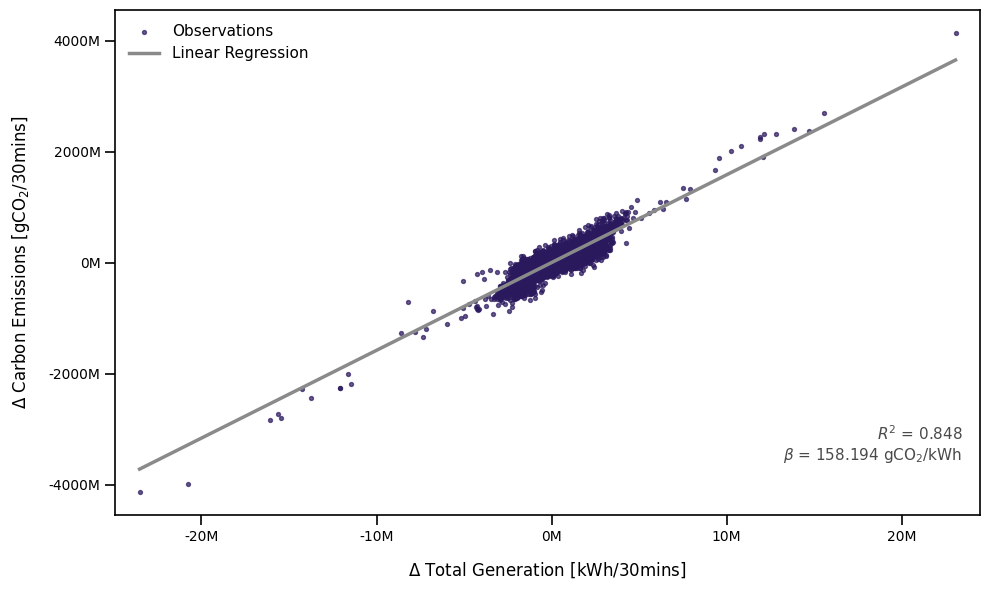

In [19]:
x = gen_diff['marginal_generation']
y = gen_diff['carbon_emissions']


slope, intercept, r_value, p_value, std_err = linregress(x, y)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, s=8, color="#2b195e", alpha=0.7, label="Observations")
x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color="#8a8a8a", linewidth=2.5, label="Linear Regression", zorder=5)

ax.set_xlabel(r'$\Delta$ Total Generation [kWh/30mins]', fontsize=12, labelpad=12)
ax.set_ylabel(r'$\Delta$ Carbon Emissions [gCO$_2$/30mins]', fontsize=12, labelpad=12)

ax.tick_params(axis='both', length=7, width=1.2, labelsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v/1e6:.0f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v/1e6:.0f}M"))
ax.legend(loc='upper left', frameon=False, fontsize=11)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

ax.margins(x=0.03, y=0.05)

ax.text(
    0.98, 0.10,
    f'$R^2$ = {r_value**2:.3f}\n'
    fr'$\beta$ = {slope:.3f} gCO$_2$/kWh',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=11, color='#4a4a4a'
)

plt.tight_layout()
plt.show()


## Marginal Emission Factors at Different Loads

Creating 40 bins for every 2.5% quantile of generation loads:

In [20]:
gen_diff['generation_load'] = (gen['generation'] + gen['generation'].shift(1)) / 2

gen_diff['generation_bin'] = pd.qcut(
    gen_diff['generation_load'].rank(method='first'),
    q=40,
    labels=False
).astype(int)

_, bin_edges = pd.qcut(
    gen_diff['generation_load'],
    q=40,
    retbins=True,
    duplicates='drop'
)

gen_diff['generation_bin'].value_counts().value_counts()

,count
count,
1314,32
1313,8


Running a linear regression for each 2.5% generation load quantile:

In [21]:
generation_bin_mean = gen_diff.groupby('generation_bin')['generation_load'].mean()

results = []
for i in sorted(gen_diff['generation_bin'].unique()):
    sub = gen_diff[gen_diff['generation_bin'] == i][['marginal_generation', 'carbon_emissions']].dropna()
    if len(sub) >= 2:
        slope, intercept, r, p, se = linregress(
            sub['marginal_generation'] * 0.5,
            sub['carbon_emissions']
        )
        results.append({
            'generation_bin': i,
            'generation_bin_mean': generation_bin_mean.loc[i],
            'marginal_emission_factor': slope
        })
    else:
        results.append({
            'generation_bin': i,
            'generation_bin_mean': generation_bin_mean.loc[i],
            'marginal_emission_factor': np.nan
        })

mef_load = pd.DataFrame(results).sort_values('generation_bin')

print(mef_load['marginal_emission_factor'].describe())
print(mef_load)

count     40.000000
mean     313.973912
std       21.120055
min      236.371366
25%      309.768856
50%      320.482857
75%      324.774231
max      335.121632
Name: marginal_emission_factor, dtype: float64
    generation_bin  generation_bin_mean  marginal_emission_factor
0                0         1.886721e+07                330.072214
1                1         2.045062e+07                303.771741
2                2         2.112707e+07                296.256061
3                3         2.166089e+07                334.181712
4                4         2.214075e+07                313.839572
5                5         2.257908e+07                282.237004
6                6         2.296345e+07                312.804850
7                7         2.331233e+07                299.257313
8                8         2.365947e+07                309.820434
9                9         2.400358e+07                318.538644
10              10         2.435461e+07                334.077785
1

## The Marginal Mix

Calculating and plotting the chnage in marginal mix at different generation loads. This visualises the contribution from each fuel type to the marginal kWh of electricity as overall generation increases.

In [22]:

marginal_change = pd.DataFrame(index=range(1, 41), columns=marginal_fuels)


for i, (bin_label, group) in enumerate(gen_diff.groupby('generation_bin'), start=1):
    for fuel in marginal_fuels:
        x = group['marginal_generation']
        y = group[fuel]

        if len(x) >= 3 and x.notna().all() and y.notna().all():
            slope, _, _, _, _ = linregress(x, y)
            marginal_change.at[i, fuel] = slope
        else:
            marginal_change.at[i, fuel] = None

marginal_change = marginal_change.astype(float)

/tmp/ipython-input-3498215834.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


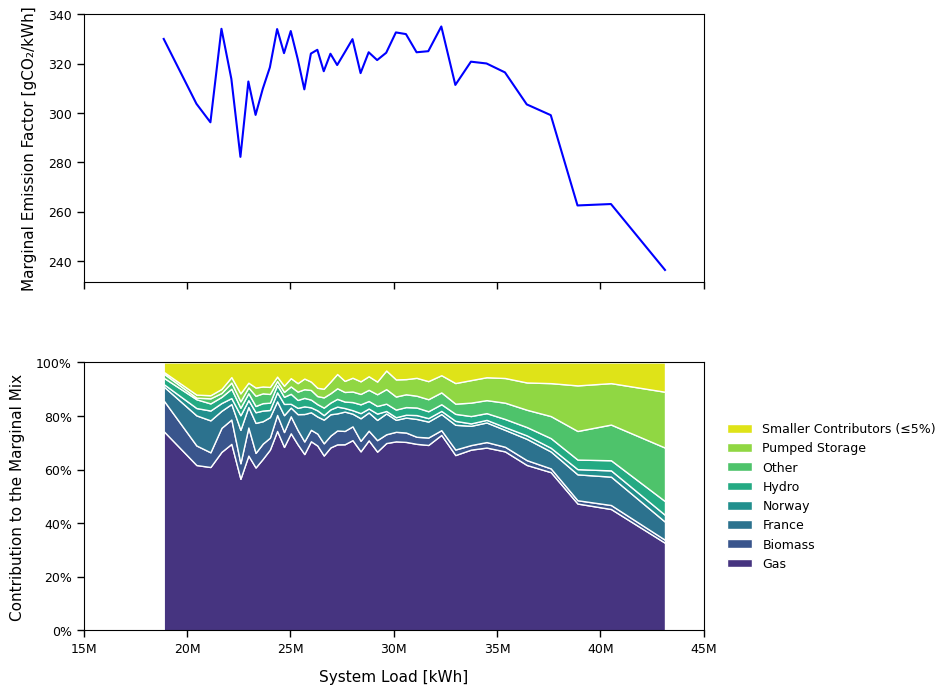

In [23]:
x_line = mef_load["generation_bin_mean"].astype(float).to_numpy()
y_line = mef_load["marginal_emission_factor"].to_numpy()

threshold = 0.05

fuel_order = sorted(
    marginal_change.columns,
    key=lambda f: marginal_change[f].iloc[-1] - marginal_change[f].iloc[0],
    reverse=False
)

x_stack = mef_load["generation_bin_mean"].astype(float).to_numpy()

Y_all = {
    f: pd.to_numeric(marginal_change[f], errors="coerce").fillna(0.0).astype(float).to_numpy()
    for f in fuel_order
}
colsum = np.sum(np.vstack(list(Y_all.values())), axis=0)
colsum_safe = np.where(colsum == 0, np.nan, colsum)

small = [f for f, y in Y_all.items() if np.nanmax(y / colsum_safe) <= threshold]
major = [f for f in fuel_order if f not in small]

labels = major.copy()
Y_list = [Y_all[f] for f in major]
if small:
    other_series = np.sum(np.vstack([Y_all[f] for f in small]), axis=0)
    labels.append("Smaller Contributors (≤5%)")
    Y_list.append(other_series)

Y = np.vstack(Y_list)
colsum2 = Y.sum(axis=0)
Y_frac = np.divide(Y, colsum2, out=np.zeros_like(Y), where=colsum2 > 0)

cmap = mpl.colormaps.get_cmap("viridis")
colors_mix = [cmap(v) for v in np.linspace(0.15, 0.95, len(labels))]

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, ncols=1, figsize=(8, 8),
    sharex=True, gridspec_kw=dict(hspace=0.3)
)

x_min, x_max = 15e6, 45e6

ax_top.plot(x_line, y_line, linewidth=1.5, color="blue")
ax_top.set_ylabel("Marginal Emission Factor [gCO₂/kWh]", fontsize=11, labelpad=8)
ax_top.set_xlim(x_min, x_max)
ax_top.tick_params(axis="both", length=5, width=1, labelsize=9, labelbottom=False)

ax_bot.stackplot(x_stack, Y_frac, labels=labels, colors=colors_mix,
                 edgecolor="white", linewidth=1.0)
ax_bot.set_xlabel("System Load [kWh]", fontsize=11, labelpad=10)
ax_bot.set_ylabel("Contribution to the Marginal Mix", fontsize=11, labelpad=8)
ax_bot.set_ylim(0, 1)
ax_bot.set_xlim(x_min, x_max)
ax_bot.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax_bot.tick_params(axis="both", length=5, width=1, labelsize=9)
ax_bot.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))

h, l = ax_bot.get_legend_handles_labels()
l_pretty = [lbl.replace('_', ' ').title() for lbl in l[::-1]]
ax_bot.legend(h[::-1], l_pretty, loc="center left", bbox_to_anchor=(1.02, 0.5),
              frameon=False, fontsize=9)

plt.tight_layout()
plt.show()



## Marginal Emission Factors at Different Times of Day


Aggregating generation data to an hourly resolution:

In [24]:
gen_even = gen.iloc[: len(gen) - (len(gen) % 2)].copy()
gen_even['pair_id'] = np.arange(len(gen_even)) // 2

gen_60 = (
    gen_even
    .groupby('pair_id', as_index=False)
    .agg({
        'date_time': 'last',
        'hour': 'last',
        'month': 'last',
        'weekday': 'last',
        'generation': 'mean',
    })
    .drop(columns='pair_id')
    .rename(columns={'generation': 'generation'})
)


Assigning generation load bins to each hourly observation:

In [25]:
gen_60['generation_bin'] = pd.cut(
    gen_60['generation'],
    bins=bin_edges,
    labels=False,
    include_lowest=True
).astype('Int64')

Creating vectors of daily generation bins so MEFs can be assigned:

In [26]:
gen_60['day'] = gen_60['date_time'].dt.floor('D')
gen_pivot_60 = gen_60.pivot(
    index='day',
    columns='hour',
    values='generation_bin'
)

gen_pivot_60.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,
2022-08-01,11,10,9,9,9,10,15,20,20,19,...,16,21,26,29,29,30,29,25,16,0
2022-08-02,0,0,9,9,10,15,22,24,26,26,...,23,26,30,31,31,30,29,26,17,11
2022-08-03,8,6,5,6,9,16,21,23,25,24,...,19,22,25,26,26,25,24,18,19,17
2022-08-04,15,14,13,13,14,20,23,24,24,22,...,21,22,25,27,26,26,25,23,18,14
2022-08-05,13,12,12,11,13,17,21,19,18,17,...,14,17,20,25,26,25,25,22,10,6


Replacing bin values with appropriate MEF values:

In [27]:
bin_to_mef = mef_load['marginal_emission_factor']
bin_to_mef.index = bin_to_mef.index.astype(int)
gen_60_mef = gen_pivot_60.apply(lambda col: col.map(bin_to_mef)).astype('float64')
gen_60_mef.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,
2022-08-01,324.307156,334.077785,318.538644,318.538644,318.538644,334.077785,324.130721,324.557182,324.557182,319.480633,...,325.667083,329.986554,332.712916,325.095903,325.095903,335.121632,325.095903,324.467562,325.667083,330.072214
2022-08-02,330.072214,330.072214,318.538644,318.538644,334.077785,324.130721,316.206829,321.492922,332.712916,332.712916,...,324.667007,332.712916,335.121632,311.415885,311.415885,335.121632,325.095903,332.712916,316.969066,324.307156
2022-08-03,309.820434,312.804850,282.237004,312.804850,318.538644,325.667083,329.986554,324.667007,324.467562,321.492922,...,319.480633,316.206829,324.467562,332.712916,332.712916,324.467562,321.492922,324.063419,319.480633,316.969066
2022-08-04,324.130721,309.614121,322.022120,322.022120,309.614121,324.557182,324.667007,321.492922,321.492922,316.206829,...,329.986554,316.206829,324.467562,332.035442,332.712916,332.712916,324.467562,324.667007,324.063419,309.614121
2022-08-05,322.022120,333.272325,333.272325,324.307156,322.022120,316.969066,329.986554,319.480633,324.063419,316.969066,...,309.614121,316.969066,324.557182,324.467562,332.712916,324.467562,324.467562,316.206829,334.077785,312.804850


Plotting MEFs at each time of day and comparing them to system to the system load:

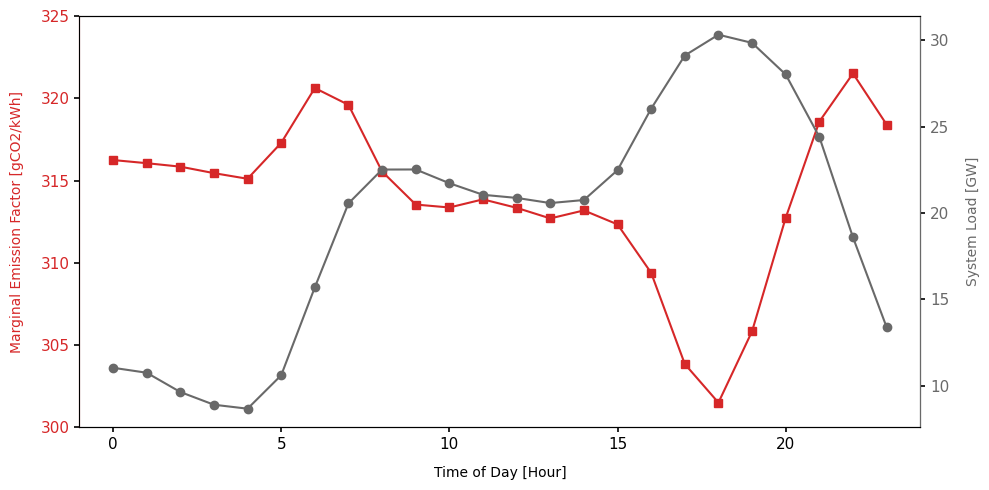

In [28]:
mean_bins = gen_pivot_60.mean(axis=0).sort_index()
mean_mef  = gen_60_mef.mean(axis=0).sort_index()

xpos   = range(len(mean_bins))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(xpos, mean_mef.values, color='tab:red', marker='s', label='Mean MEF')
ax1.set_ylabel("Marginal Emission Factor [gCO2/kWh]", color='tab:red', labelpad=12)
ax1.tick_params(axis='y', labelcolor='tab:red', width=1.2, labelsize=11)
ax1.set_ylim(300, 325)
ax1.set_yticks(np.arange(300, 326, 5))
ax1.spines['left'].set_color('tab:red')

ax2 = ax1.twinx()
ax2.plot(xpos, mean_bins.values, color='dimgray', marker='o', label='System Load')
ax2.set_ylabel("System Load [GW]", color='dimgray', labelpad=12)
ax2.tick_params(axis='y', labelcolor='dimgray', width=1.2, labelsize=11)
ax2.spines['right'].set_color('dimgray')

ax1.set_xlabel("Time of Day [Hour]", labelpad=10)
ax1.set_xlim(-1, 24)
ax1.set_xticks(np.arange(0, 21, 5))
ax1.tick_params(axis='x', width=1.2, labelsize=11)

plt.tight_layout()
plt.show()



Sampling 100 random daily MEF vectors for pice optimisation to simulate through

In [29]:
mef_sample = gen_60_mef.sample(n=100, random_state=42)
mef_sample.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,
2024-01-16,320.846283,320.846283,311.415885,335.121632,325.095903,335.121632,320.119430,262.530746,236.371366,236.371366,...,236.371366,236.371366,236.371366,236.371366,236.371366,236.371366,236.371366,263.111316,299.155092,320.846283
2022-12-18,329.986554,316.206829,324.557182,316.969066,309.614121,333.272325,324.130721,319.480633,324.667007,325.095903,...,262.530746,262.530746,262.530746,263.111316,263.111316,299.155092,316.496363,311.415885,332.035442,321.492922
2022-10-28,313.839572,282.237004,313.839572,313.839572,299.257313,322.022120,324.467562,311.415885,320.119430,320.119430,...,332.712916,325.095903,320.846283,316.496363,316.496363,311.415885,325.095903,321.492922,324.130721,312.804850
2024-11-19,325.667083,316.969066,316.969066,316.969066,324.130721,316.969066,324.667007,320.119430,262.530746,263.111316,...,236.371366,236.371366,236.371366,236.371366,236.371366,236.371366,263.111316,299.155092,320.846283,324.467562
2025-04-12,312.804850,282.237004,334.181712,296.256061,296.256061,334.181712,312.804850,334.077785,334.077785,312.804850,...,282.237004,309.820434,324.130721,316.206829,324.667007,316.206829,329.986554,316.969066,309.820434,313.839572


## Exporting Data



Saving the MEF estimates at hourly intervals to be used in price optimisation:

In [30]:
mef_sample.to_csv("/content/drive/MyDrive/ERP/Processed_Data/mef_sample.csv")